⚠️ Using CPU
Mounted at /content/drive
Loading data...
✅ Data Ready. Input features: 65
🚀 Starting SOTA Tapered Training...
Epoch 1/80
1788/1791 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.9046 - loss: 0.9790
Epoch 1: val_accuracy improved from -inf to 0.98067, saving model to /content/drive/MyDrive/SignApp/model_final_tapered.keras
1791/1791 ━━━━━━━━━━━━━━━━━━━━ 43s 22ms/step - accuracy: 0.9047 - loss: 0.9787 - val_accuracy: 0.9807 - val_loss: 0.7134
Epoch 2/80
1789/1791 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.9737 - loss: 0.7340
Epoch 2: val_accuracy improved from 0.98067 to 0.98690, saving model to /content/drive/MyDrive/SignApp/model_final_tapered.keras
1791/1791 ━━━━━━━━━━━━━━━━━━━━ 38s 21ms/step - accuracy: 0.9737 - loss: 0.7340 - val_accuracy: 0.9869 - val_loss: 0.6932
Epoch 3/80
1790/1791 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.9788 - loss: 0.7151
Epoch 3: val_accuracy did not improve from 0.98690
1791/1791 ━━━━━━━━━━━━━━━━━━━━ 37s 20ms/step - accuracy: 0.97

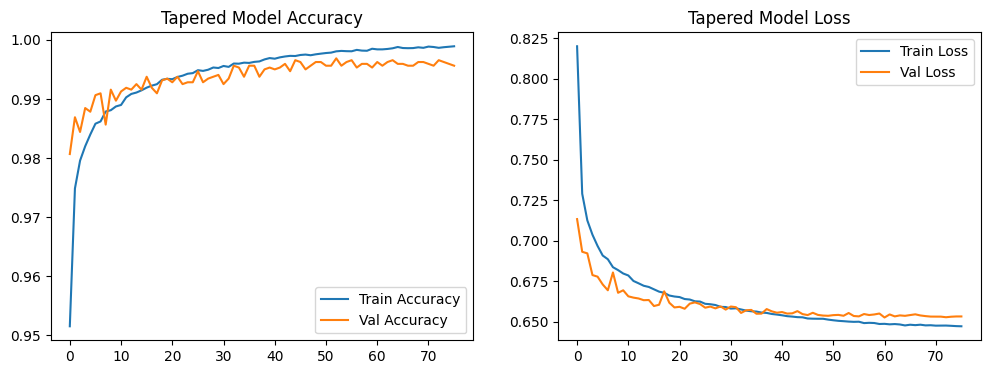


🏆 FINAL TAPERED TEST ACCURACY: 99.53%


In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import pickle
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Activation, Input
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.utils import to_categorical
from google.colab import drive

# --- 0. DEVICE CHECK ---
device_name = tf.test.gpu_device_name()
print(f"✅ Using GPU: {device_name}" if device_name else "⚠️ Using CPU")

drive.mount('/content/drive')
base_path = '/content/drive/MyDrive/SignApp/'

# --- 1. FEATURE ENGINEERING ---
def add_engineered_features(X_raw):
    """Adds pinch distances to distinguish similar signs like M, N, T, S."""
    X_reshaped = X_raw.reshape(-1, 21, 3)
    # Distances from Thumb Tip (4) to Index MCP (5) and Pinky MCP (17)
    thumb_tip = X_reshaped[:, 4, :]
    index_mcp = X_reshaped[:, 5, :]
    pinky_mcp = X_reshaped[:, 17, :]

    dist1 = np.linalg.norm(thumb_tip - index_mcp, axis=1, keepdims=True)
    dist2 = np.linalg.norm(thumb_tip - pinky_mcp, axis=1, keepdims=True)
    return np.hstack([X_raw, dist1, dist2])

# --- 2. LOAD & PREPARE ---
print("Loading data...")
df = pd.read_csv(base_path + 'landmarks_normalized.csv')
X = df.drop('label', axis=1).values
y_labels = df['label'].values

encoder = LabelEncoder()
y_one_hot = to_categorical(encoder.fit_transform(y_labels))
X_enhanced = add_engineered_features(X)

# Save encoder for use in the Streamlit App
with open(base_path + 'label_encoder.p', 'wb') as f:
    pickle.dump(encoder, f)

print(f"✅ Data Ready. Input features: {X_enhanced.shape[1]}")

# --- 3. SPLIT & AUGMENTATION (JITTERING) ---
X_temp, X_test, y_temp, y_test = train_test_split(
    X_enhanced, y_one_hot, test_size=0.05, stratify=y_one_hot, random_state=42
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.053, stratify=y_temp, random_state=42
)

# Augment Training Set with 0.5% Gaussian Jitter
noise = np.random.normal(0, 0.005, X_train.shape)
X_train_aug = np.vstack([X_train, X_train + noise])
y_train_aug = np.vstack([y_train, y_train])

# --- 4. SOTA SCHEDULER & TAPERED MODEL ---
EPOCHS = 80 # Increased epochs for larger model convergence
BATCH_SIZE = 64
steps_per_epoch = len(X_train_aug) // BATCH_SIZE

lr_schedule = tf.keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=0.001,
    decay_steps=EPOCHS * steps_per_epoch,
    alpha=0.0001
)



model = Sequential([
    Input(shape=(X_enhanced.shape[1],)),

    # Layer 1: Massive Initial Capacity
    Dense(1024), BatchNormalization(), Activation('relu'), Dropout(0.4),

    # Layer 2: Feature Extraction
    Dense(512),  BatchNormalization(), Activation('relu'), Dropout(0.3),

    # Layer 3: Compression
    Dense(256),  BatchNormalization(), Activation('relu'), Dropout(0.2),

    # Layer 4: Fine-tuning
    Dense(128),  BatchNormalization(), Activation('relu'),

    # Output
    Dense(len(encoder.classes_), activation='softmax')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=lr_schedule),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy']
)

# --- 5. TRAINING ---
checkpoint = ModelCheckpoint(
    base_path + 'model_final_tapered.keras',
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)

print("🚀 Starting SOTA Tapered Training...")
history = model.fit(
    X_train_aug, y_train_aug,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_val, y_val),
    callbacks=[checkpoint, early_stop],
    verbose=1
)

# --- 6. VISUALIZATION ---


plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Tapered Model Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Tapered Model Loss')
plt.legend()
plt.show()

# --- 7. FINAL HOLD-OUT TEST ---
best_m = load_model(base_path + 'model_final_tapered.keras')
test_loss, test_acc = best_m.evaluate(X_test, y_test, verbose=0)
print(f"\n🏆 FINAL TAPERED TEST ACCURACY: {test_acc*100:.2f}%")

100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


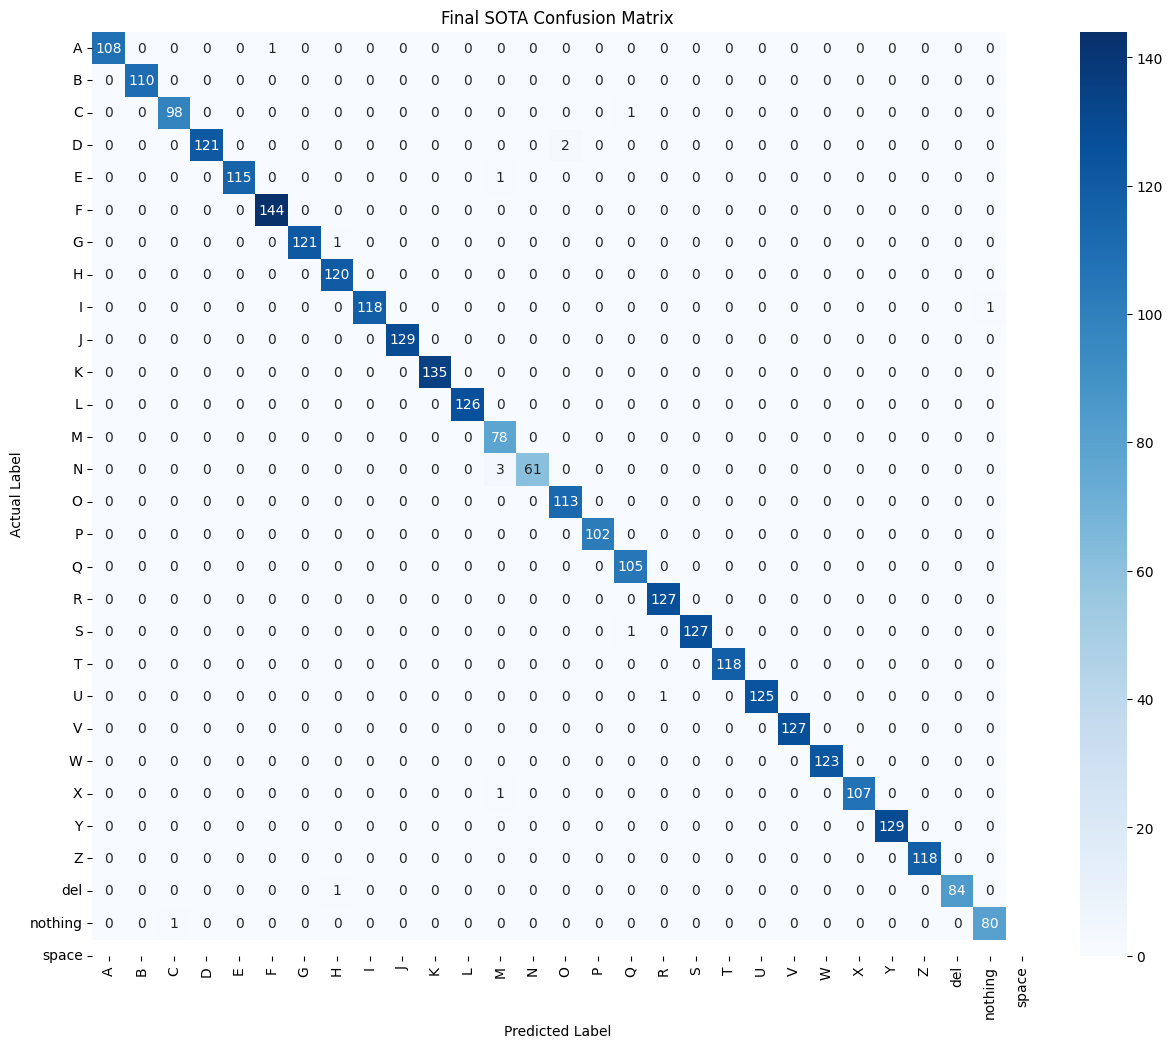

In [ ]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 1. Predict on the Test Set
y_pred_probs = best_m.predict(X_test)
y_pred_classes = np.argmax(y_pred_probs, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

# 2. Generate Confusion Matrix
cm = confusion_matrix(y_true_classes, y_pred_classes)
plt.figure(figsize=(15, 12))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=encoder.classes_,
            yticklabels=encoder.classes_)
plt.title('Final SOTA Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()